In [ ]:
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties ,fontManager
import seaborn as sns
import numpy as np
import pandas as pd

# Times New Roman，
font_path = '../classify/fonts/times.ttf'
fontManager.addfont(path=font_path)
prop = FontProperties(fname=font_path)

sns.set(context='paper', 
        style='ticks', 
        palette='deep', 
        font=prop.get_name(),
        font_scale=2.8, 
        rc={
            'mathtext.fontset': 'stix',
            'pdf.fonttype': 42,
            'lines.linewidth' : 4,
            'lines.markersize' : 8,
            'font.weight': 'bold',
            'axes.labelweight': 'bold',
            'axes.titleweight': 'bold',
            'figure.titleweight': 'bold'
        }
)
sns.despine()

<Figure size 640x480 with 0 Axes>

In [ ]:
# Set Times New Roman font, bold
plt.rcParams.update(
    {
            'font.family': 'serif',
            'font.serif' : 'Times New Roman',
            'font.size'   : 14,
            'pdf.fonttype': 42,
            'lines.linewidth' : 4,
            'lines.markersize' : 8,
            'font.weight': 'bold',
            'axes.labelweight': 'bold',
            'axes.titleweight': 'bold',
            'figure.titleweight': 'bold'
        }
)
sns.despine()

In [ ]:
import pickle as pkl
train_files = ['original_population_train.pkl'] + ['final_population_{}.pkl'.format(i) for i in range(1, 5)]
eval_files = ['original_population_eval.pkl'] + ['final_population_{}_eval.pkl'.format(i) for i in range(1, 5)]

train_files = ['mutation_all/mutations/' + f for f in train_files]
eval_files = ['mutation_all/mutations/' + f for f in eval_files]

train_res = []
eval_res = []
for file in train_files:
    with open(file, 'rb') as f:
        res = pkl.load(f)
        train_res.append(res)

for file in eval_files:
    with open(file, 'rb') as f:
        res = pkl.load(f)
        eval_res.append(res)

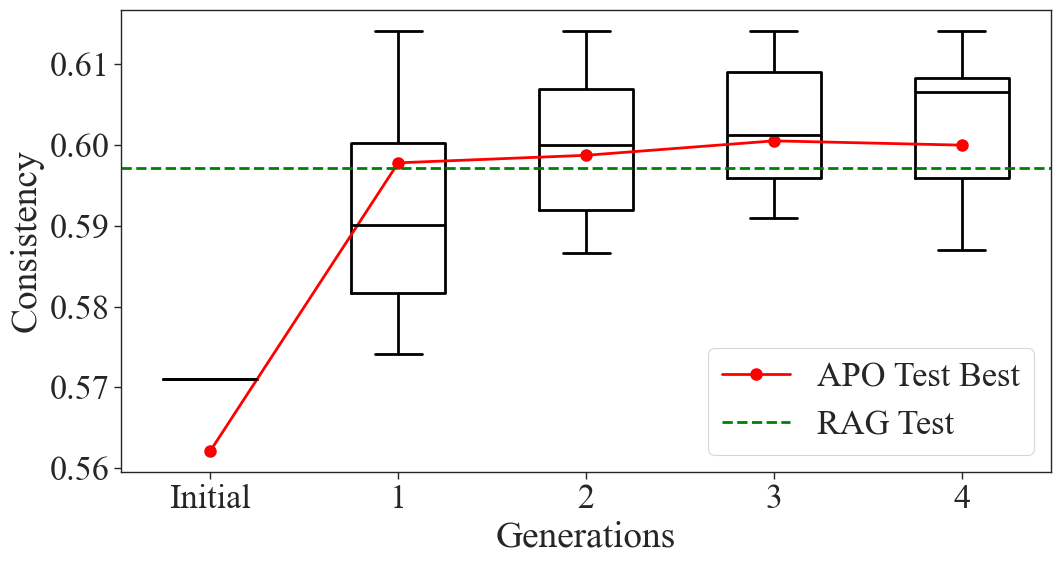

In [9]:
# res['consistencies'] -> list of metrics, only draw train in boxplot, without color
train_consistencies = [res['consistencies'] for res in train_res]
rag_baseline = 0.59718
plt.figure(figsize=(12, 6))
sns.boxplot(data=train_consistencies,
            orient='v',
            width=0.5,
            showfliers=False,
            linewidth=2,
            fill=False,
            color='black',
)
plt.xlabel('Generations')
plt.ylabel('Consistency')
#plt.title('Consistency of Prompts in Training Generations')
#draw line for train results
# train_consistencies_mean = [np.mean(res['consistencies']) for res in train_res]
# plt.plot(range(0, 5), train_consistencies_mean, marker='o', color='red', linewidth=1, label='APO Train Mean', linestyle='--')


#draw eval results at generation by line
eval_consistencies = [max(res['consistencies']) for res in eval_res]
plt.plot(range(0, 5), eval_consistencies, marker='o', color='red', linewidth=2, label='APO Test Best')

#draw rag baseline
plt.axhline(y=rag_baseline, color='green', linestyle='--', linewidth=2, label='RAG Test')
plt.legend(loc='lower right')
plt.xticks(range(0, 5), ['Initial', '1', '2', '3', '4'])
plt.yticks()
plt.savefig('consistency_plot.pdf', bbox_inches='tight')